In [1]:
import os, re, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [6]:
ZIP_PATH = r"C:\Users\HP\Downloads\Air polluation  indicator dataset.zip"
EXTRACT_DIR = '/content/air_pollution_dataset'

import zipfile, os, pandas as pd
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

LABEL_MAP = {'Good':'Good','Mod':'Moderate','MOD':'Moderate','UH':'Unhealthy','UHFSG':'Unhealthy_Sensitive','UnFSG':'Unhealthy_Sensitive','VUH':'Very_Unhealthy','VUnH':'Very_Unhealthy','UnH':'Unhealthy','UN':'Unknown'}
records = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        
        if not f.endswith('.jpg'): continue
        filepath = os.path.join(root, f)
        city = os.path.basename(root)
        parts = f.split('_')
        label = 'Unknown'
        if len(parts) >= 2:
            code = parts[1]
            label = LABEL_MAP.get(code, 'Unknown')
        records.append({'path': filepath, 'label': label, 'city': city})
df = pd.DataFrame(records)
df = df[df['label'] != 'Unknown']
print(df['label'].value_counts())

label
Unhealthy_Sensitive    1486
Moderate               1164
Very_Unhealthy          907
Unhealthy               743
Good                    667
Name: count, dtype: int64


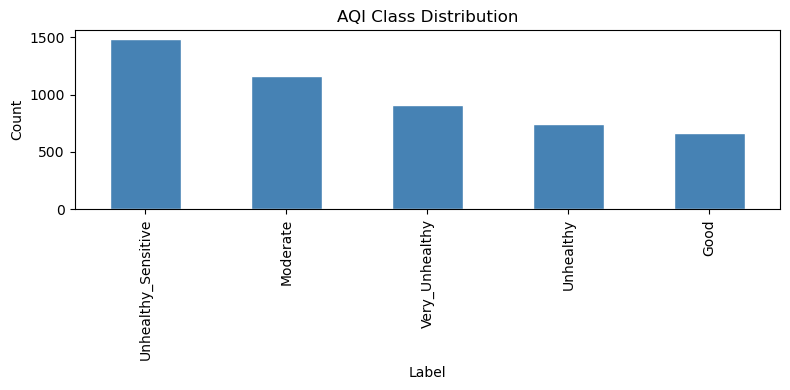

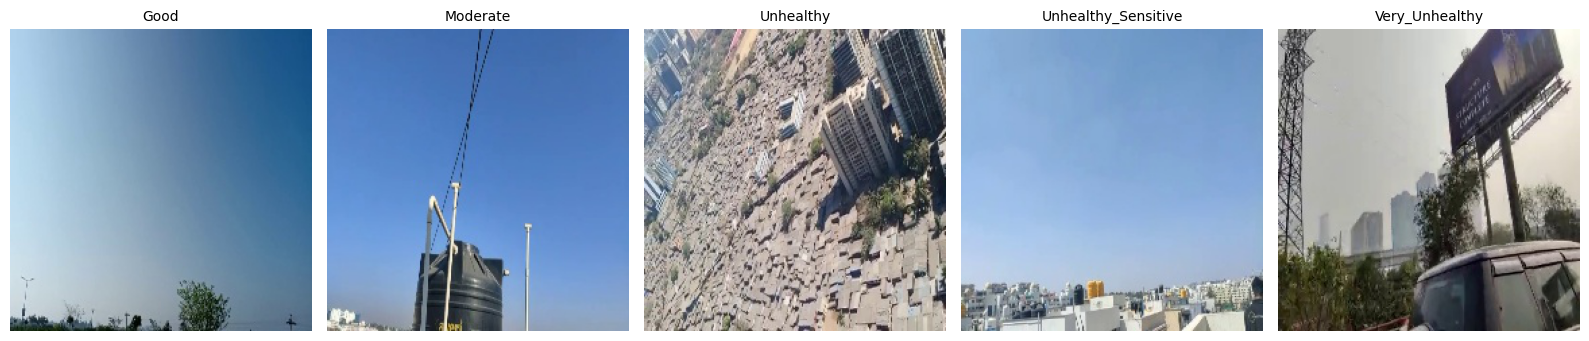

In [7]:
plt.figure(figsize=(8, 4))
df['label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('AQI Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, df['label'].nunique(), figsize=(16, 4))
for ax, (label, grp) in zip(axes, df.groupby('label')):
    img = Image.open(grp.sample(1)['path'].values[0])
    ax.imshow(img)
    ax.set_title(label, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
IMG_SIZE = (128, 128)

def load_image(path):
    try:
        img = Image.open(path).convert('RGB').resize(IMG_SIZE)
        return np.array(img) / 255.0
    except:
        return None
X, y = [], []
for _, row in tqdm(df.iterrows(), total=len(df)):
    img = load_image(row['path'])
    if img is not None:
        X.append(img)
        y.append(row['label'])
X = np.array(X, dtype='float32')
y = np.array(y)
le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)
print(f'Classes: {le.classes_}')
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y_enc, test_size=0.30, stratify=y_enc, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

100%|██████████| 4967/4967 [00:18<00:00, 266.41it/s]


Classes: ['Good' 'Moderate' 'Unhealthy' 'Unhealthy_Sensitive' 'Very_Unhealthy']


In [9]:
base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
base.trainable = False

inputs = tf.keras.Input(shape=(128, 128, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,912 (16.72 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [12]:
BATCH = 32
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH).map(lambda x, y: (augment(x, training=True), y)).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [13]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss'),
]
history1 = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks, verbose=1)
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history2 = model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=callbacks, verbose=1)

Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 81s 733ms/step - accuracy: 0.3268 - loss: 1.4980 - val_accuracy: 0.3718 - val_loss: 1.4532 - learning_rate: 5.0000e-05
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 89s 801ms/step - accuracy: 0.3352 - loss: 1.4860 - val_accuracy: 0.3060 - val_loss: 1.4241 - learning_rate: 5.0000e-05
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 132s 708ms/step - accuracy: 0.3446 - loss: 1.4645 - val_accuracy: 0.3235 - val_loss: 1.3986 - learning_rate: 5.0000e-05
Epoch 4/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 88s 805ms/step - accuracy: 0.3458 - loss: 1.4541 - val_accuracy: 0.2550 - val_loss: 1.5362 - learning_rate: 5.0000e-05
Epoch 5/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 87s 797ms/step - accuracy: 0.3631 - loss: 1.4599 - val_accuracy: 0.3235 - val_loss: 1.4380 - learning_rate: 5.0000e-05
Epoch 6/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 134s 720ms/step - accuracy: 0.3633 - loss: 1.4266 - val_accuracy: 0.3812 - val_loss: 1.4476 - learning_rate: 5.0000e-05
Epoch 7/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 82s 

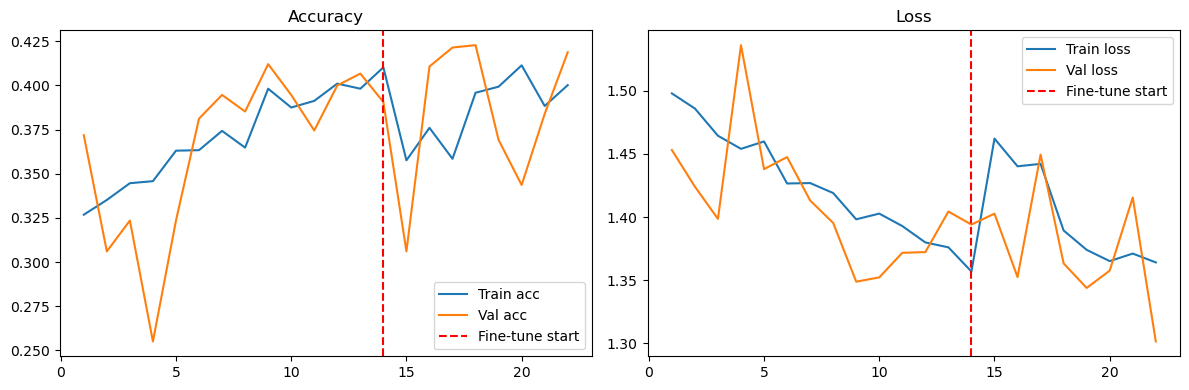

In [21]:
def plot_history(h1, h2):
    acc  = h1.history['accuracy']     + h2.history['accuracy']
    val  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss']         + h2.history['loss']
    vloss= h1.history['val_loss']     + h2.history['val_loss'], 
    ep   = range(1, len(acc) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4  ))
    ax1.plot(ep, acc, label='Train acc')
    ax1.plot(ep, val, label='Val acc')
    ax1.axvline(len(h1.history['accuracy']), color='red', ls='--', label='Fine-tune start')
    ax1.set_title('Accuracy'); ax1.legend()
    ax2.plot(ep, loss, label='Train loss')
    ax2.plot(ep, vloss[0], label='Val loss')
    ax2.axvline(len(h1.history['loss']), color='red', ls='--', label='Fine-tune start')
    ax2.set_title('Loss'); ax2.legend()
    plt.tight_layout(); plt.show()

plot_history(history1, history2)

24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 496ms/step - accuracy: 0.4357 - loss: 1.3504
Test Accuracy: 0.4357
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 543ms/step
                     precision    recall  f1-score   support

               Good       0.27      0.09      0.14       100
           Moderate       0.85      0.31      0.46       175
          Unhealthy       0.76      0.17      0.28       112
Unhealthy_Sensitive       0.35      0.86      0.49       223
     Very_Unhealthy       0.69      0.38      0.49       136

           accuracy                           0.44       746
          macro avg       0.58      0.36      0.37       746
       weighted avg       0.58      0.44      0.40       746



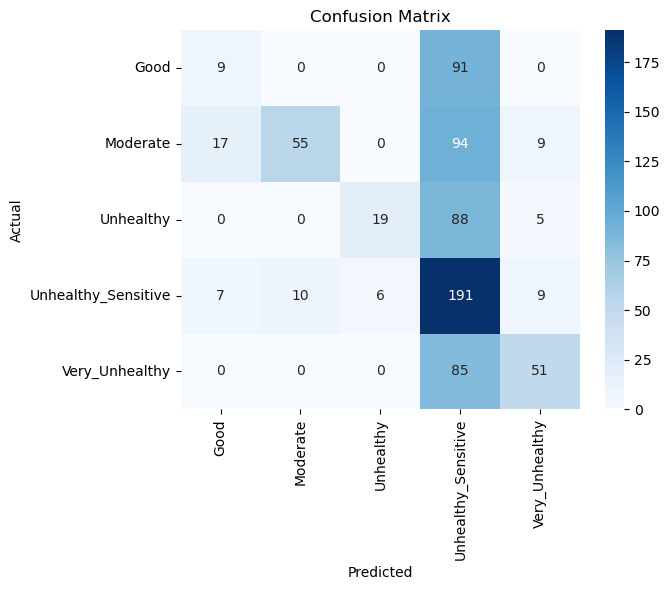

In [22]:
loss, acc = model.evaluate(test_ds)
print(f'Test Accuracy: {acc:.4f}')

y_pred = np.argmax(model.predict(test_ds), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [23]:
SEQ_LEN = 10
df_sorted = df.copy()
df_sorted['label_enc'] = le.transform(df_sorted['label'])

def make_sequences(series, seq_len):
    Xs, ys = [], []
    for i in range(len(series) - seq_len):
        Xs.append(series[i: i + seq_len])
        ys.append(series[i + seq_len])
    return np.array(Xs), np.array(ys)

seq_data = df_sorted.groupby('city')['label_enc'].apply(list)
all_X, all_y = [], []
for city_series in seq_data:
    Xs, ys = make_sequences(city_series, SEQ_LEN)
    all_X.extend(Xs); all_y.extend(ys)

Xl = np.array(all_X)[..., np.newaxis]
yl = np.array(all_y)
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(Xl, yl, test_size=0.2, random_state=42)

lstm_model = models.Sequential([
    layers.LSTM(64, input_shape=(SEQ_LEN, 1), return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dense(num_classes, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(Xl_tr, yl_tr, validation_split=0.15, epochs=30, batch_size=64, verbose=1)

Epoch 1/30


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5548 - loss: 1.0814 - val_accuracy: 0.9865 - val_loss: 0.3414
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9904 - loss: 0.1624 - val_accuracy: 0.9865 - val_loss: 0.1167
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9895 - loss: 0.0739 - val_accuracy: 0.9865 - val_loss: 0.0919
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9898 - loss: 0.0620 - val_accuracy: 0.9865 - val_loss: 0.0970
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9907 - loss: 0.0577 - val_accuracy: 0.9865 - val_loss: 0.0822
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9895 - loss: 0.0523 - val_accuracy: 0.9865 - val_loss: 0.0763
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9910 - loss: 0.0509 - val_accuracy: 0.9865 - val_loss: 0.0660
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9922 - loss: 0.0434 - val_accuracy: 0.9865 - val_loss: 0.

In [24]:
model.save('aqi_cnn_model.h5')
lstm_model.save('aqi_lstm_model.h5')
print('Models saved!')

def predict_image(img_path, model, le, img_size=(128, 128)):
    img = Image.open(img_path).convert('RGB').resize(img_size)
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr)[0]
    pred_idx = np.argmax(probs)
    pred_label = le.classes_[pred_idx]
    confidence = probs[pred_idx]
    print(f'Predicted AQI: {pred_label} ({confidence:.1%} confidence)')
    plt.imshow(img)
    plt.title(f'{pred_label} — {confidence:.1%}')
    plt.axis('off'); plt.show()
    return pred_label

Models saved!


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# Upload Widget
upload_btn = widgets.FileUpload(
    accept='.jpg,.png,.jpeg',
    multiple=False
)

predict_btn = widgets.Button(
    description='Predict',
    button_style='success'
)

out = widgets.Output()

# Prediction Function
def on_predict(b):

    with out:
        clear_output()

        if not upload_btn.value:
            print("Upload an image first.")
            return

        # Read image
        uploaded = upload_btn.value[0]

        img_bytes = uploaded['content']

        img = Image.open(
            io.BytesIO(img_bytes)
        ).convert('RGB')

        img = img.resize((128, 128))

        # Prepare image
        img_arr = np.array(img) / 255.0
        img_arr = np.expand_dims(img_arr, axis=0)

        # Predict
        pred = model.predict(img_arr, verbose=0)[0]

        pred_idx = np.argmax(pred)

        pred_class = le.classes_[pred_idx]

        confidence = pred[pred_idx] * 100

        # Plot
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))

        # Image
        ax[0].imshow(img)
        ax[0].axis('off')
        ax[0].set_title("Uploaded Image")

        # Probability Chart
        labels = le.classes_
        values = pred * 100

        colors = [
            'green' if i == pred_idx else 'gray'
            for i in range(len(labels))
        ]

        ax[1].barh(labels, values, color=colors)

        ax[1].set_xlim(0, 100)
        ax[1].set_xlabel("Confidence %")
        ax[1].set_title("Prediction Probabilities")

        for i, v in enumerate(values):
            ax[1].text(v + 1, i, f"{v:.1f}%")

        plt.tight_layout()
        plt.show()

        # Result
        print("=" * 40)
        print("AQI PREDICTION RESULT")
        print("=" * 40)

        print("Predicted Class :", pred_class)

        print("Confidence      :", f"{confidence:.2f}%")

        # AQI Status
        if pred_class == "Good":
            print("Air Quality     : Safe")

        elif pred_class == "Moderate":
            print("Air Quality     : Moderate")

        else:
            print("Air Quality     : Harmful")

# Button Event
predict_btn.on_click(on_predict)

# Display
display(upload_btn, predict_btn, out)

FileUpload(value=(), accept='.jpg,.png,.jpeg', description='Upload')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()